In [3]:
from google.colab import files

uploaded = files.upload()

Saving Leads.csv to Leads.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('/content/Leads.csv')

df.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [6]:
print(df.shape)
print(df.columns.tolist())
df.info()

(9240, 37)
['Prospect ID', 'Lead Number', 'Lead Origin', 'Lead Source', 'Do Not Email', 'Do Not Call', 'Converted', 'TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit', 'Last Activity', 'Country', 'Specialization', 'How did you hear about X Education', 'What is your current occupation', 'What matters most to you in choosing a course', 'Search', 'Magazine', 'Newspaper Article', 'X Education Forums', 'Newspaper', 'Digital Advertisement', 'Through Recommendations', 'Receive More Updates About Our Courses', 'Tags', 'Lead Quality', 'Update me on Supply Chain Content', 'Get updates on DM Content', 'Lead Profile', 'City', 'Asymmetrique Activity Index', 'Asymmetrique Profile Index', 'Asymmetrique Activity Score', 'Asymmetrique Profile Score', 'I agree to pay the amount through cheque', 'A free copy of Mastering The Interview', 'Last Notable Activity']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column         

In [7]:
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

,0
Lead Quality,4767
Asymmetrique Profile Score,4218
Asymmetrique Activity Index,4218
Asymmetrique Activity Score,4218
Asymmetrique Profile Index,4218
Tags,3353
What matters most to you in choosing a course,2709
Lead Profile,2709
What is your current occupation,2690
Country,2461


In [8]:
missing_percent = (df.isnull().sum()/len(df))*100

cols_to_drop = missing_percent[
    missing_percent > 40
].index

df = df.drop(columns=cols_to_drop)

print(df.shape)

(9240, 32)


In [9]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

In [10]:
print(df['Converted'].value_counts())

Converted
0    5679
1    3561
Name: count, dtype: int64


In [11]:
conversion_rate = df['Converted'].mean()*100
print(f"Overall Conversion Rate: {conversion_rate:.2f}%")

Overall Conversion Rate: 38.54%


In [12]:
origin_conversion = (
    df.groupby('Lead Origin')['Converted']
      .mean()*100
)

origin_conversion.sort_values(
    ascending=False
)

,Converted
Lead Origin,
Quick Add Form,100.000000
Lead Add Form,92.479109
Landing Page Submission,36.185018
API,31.145251
Lead Import,23.636364


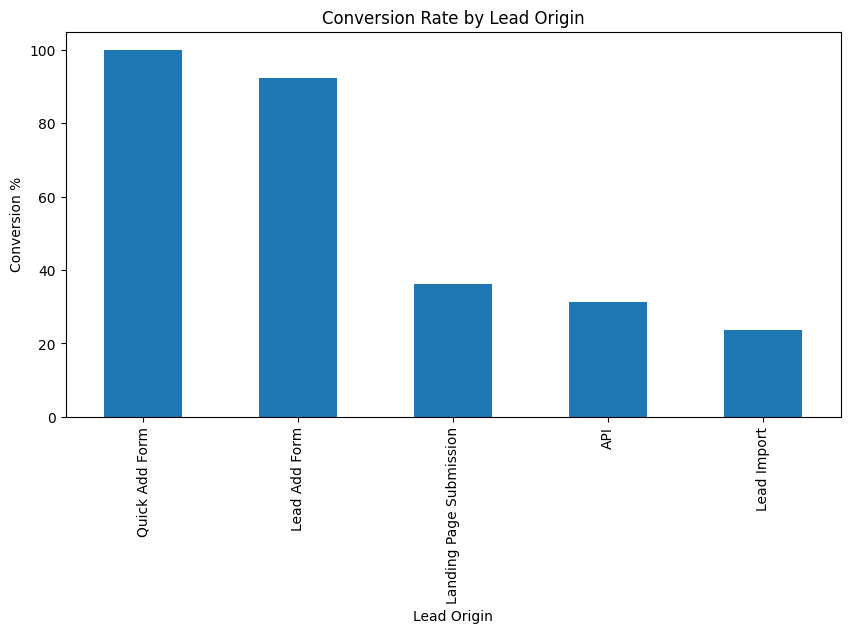

In [13]:
plt.figure(figsize=(10,5))
origin_conversion.sort_values(
    ascending=False
).plot(kind='bar')

plt.title("Conversion Rate by Lead Origin")
plt.ylabel("Conversion %")
plt.show()

In [14]:
source_conversion = (
    df.groupby('Lead Source')['Converted']
      .mean()*100
)

source_conversion.sort_values(
    ascending=False
).head(10)

,Converted
Lead Source,
Live Chat,100.000000
WeLearn,100.000000
NC_EDM,100.000000
Welingak Website,98.591549
Reference,91.760300
Click2call,75.000000
Social Media,50.000000
Google,40.495868
Organic Search,37.781629


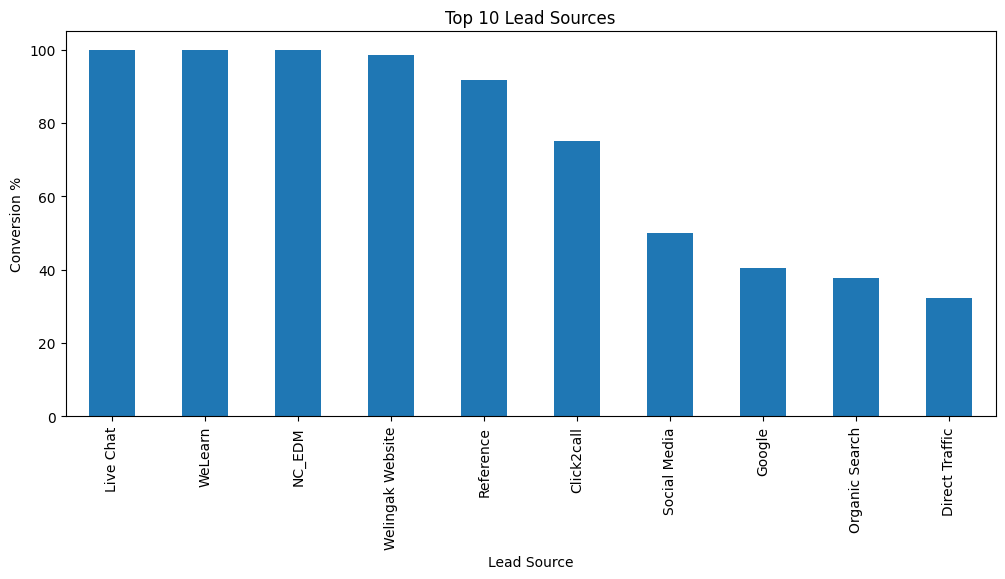

In [15]:
plt.figure(figsize=(12,5))

source_conversion.sort_values(
    ascending=False
).head(10).plot(kind='bar')

plt.title("Top 10 Lead Sources")
plt.ylabel("Conversion %")
plt.show()

In [16]:
total_leads = len(df)

converted = df['Converted'].sum()

funnel = pd.DataFrame({
    'Stage':['Leads','Customers'],
    'Count':[total_leads, converted]
})

funnel

,Stage,Count
0,Leads,9240
1,Customers,3561


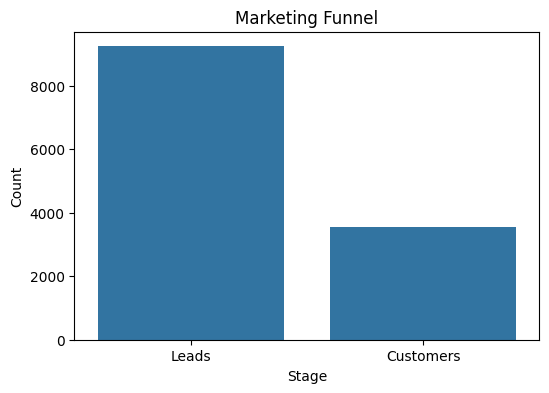

In [17]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=funnel,
    x='Stage',
    y='Count'
)

plt.title("Marketing Funnel")
plt.show()

In [19]:
occupation_conversion = (
    df.groupby('What is your current occupation')['Converted']
      .mean()*100
)
occupation_conversion.sort_values(
    ascending=False
).head(10)

,Converted
What is your current occupation,
Housewife,100.000000
Working Professional,91.643059
Businessman,62.500000
Other,62.500000
Student,37.142857
Unemployed,33.908323


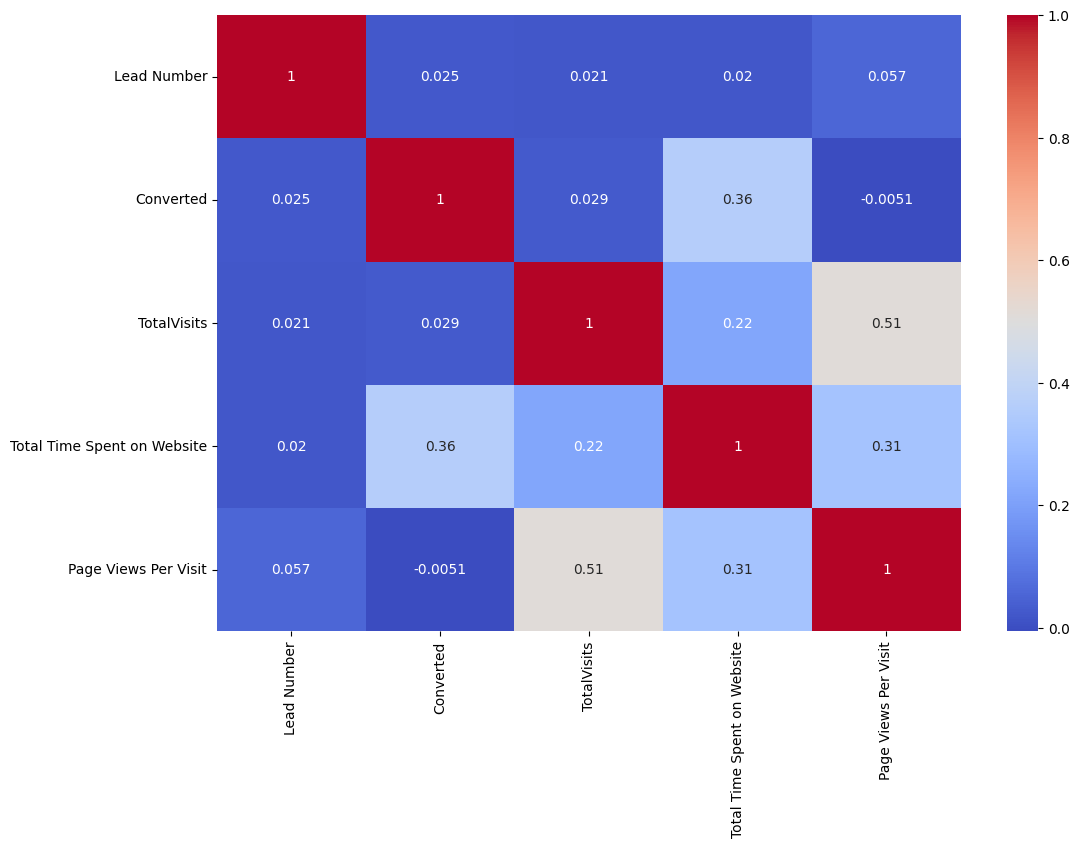

In [20]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()